# Main - run all 9 stages

In [1]:
import os, sys
ROOT = os.getcwd()
while not os.path.exists(os.path.join(ROOT, "src", "config.py")):
    parent = os.path.dirname(ROOT)
    if parent == ROOT:
        raise RuntimeError("Project root (folder containing src/) not found")
    ROOT = parent
os.chdir(ROOT)
sys.path.insert(0, ROOT)
os.makedirs("results/figures", exist_ok=True)

In [2]:
import time, nbformat
from nbclient import NotebookClient

STAGE_NOTEBOOKS = [
    "stage_01_classical_gci_model.ipynb",
    "stage_02_quantum_encoding.ipynb",
    "stage_03_circuit_design.ipynb",
    "stage_04_classical_training.ipynb",
    "stage_05_transpilation.ipynb",
    "stage_06_hardware_retuning.ipynb",
    "stage_07_run_on_backend.ipynb",
    "stage_08_classical_postprocessing.ipynb",
    "stage_09_var_fidelity_check.ipynb",
]

RUN_FROM = 1
RUN_TO = 9

os.environ["PATH"] = os.path.dirname(sys.executable) + os.pathsep + os.environ.get("PATH", "")
FOLDER = os.path.join(ROOT, "project_code")

t_all = time.time()
for i in range(RUN_FROM, RUN_TO + 1):
    name = STAGE_NOTEBOOKS[i - 1]
    path = os.path.join(FOLDER, name)
    t0 = time.time()
    print(f"Stage {i}: running {name} ...", flush=True)
    nb = nbformat.read(path, as_version=4)
    NotebookClient(nb, timeout=3600, kernel_name="python3",
                   resources={"metadata": {"path": FOLDER}}).execute()
    nbformat.write(nb, path)
    print(f"Stage {i}: done in {time.time() - t0:.1f} s", flush=True)
print(f"\nAll stages finished in {time.time() - t_all:.1f} s")

Stage 1: running stage_01_classical_gci_model.ipynb ...


[IPKernelApp] WARNING | Kernel is running over TCP without encryption. All communication (including code and outputs) is sent in plain text and is susceptible to eavesdropping. Use IPC transport or launch with kernel manager-provisioned CurveZMQ keys to enable transport encryption.


Stage 1: done in 3.4 s


Stage 2: running stage_02_quantum_encoding.ipynb ...


[IPKernelApp] WARNING | Kernel is running over TCP without encryption. All communication (including code and outputs) is sent in plain text and is susceptible to eavesdropping. Use IPC transport or launch with kernel manager-provisioned CurveZMQ keys to enable transport encryption.


...

Stage 8: done in 4.8 s


Stage 9: running stage_09_var_fidelity_check.ipynb ...


[IPKernelApp] WARNING | Kernel is running over TCP without encryption. All communication (including code and outputs) is sent in plain text and is susceptible to eavesdropping. Use IPC transport or launch with kernel manager-provisioned CurveZMQ keys to enable transport encryption.


Stage 9: done in 10.3 s



All stages finished in 89.7 s


In [3]:
import json
from src import config as C

s6 = json.load(open("results/stage06_retuning.json"))
s9 = json.load(open("results/stage09_final_report.json"))

print("STAGE 6 - calibration of the full GCI circuit on the noisy device")
print(f"{'register':>8} | {'method':30s} | {'circuit runs':>12} | {'Hellinger fidelity':>18}")
for n in C.REGISTER_SIZES:
    g = s6[f"{n}_qubit"]["gci"]
    print(f"{n:>7}q | {'uncalibrated (Stage 4 angles)':30s} | {0:>12} | {g['uncalibrated']['fidelity']:18.4f}")
    for k, lab in [("grid_6A", "6A grid sweep (base paper)"), ("auto_6B", "6B automated (this project)")]:
        m = g["methods"][k]
        print(f"{n:>7}q | {lab:30s} | {m['n_evals']:>12} | {m['fidelity']:18.4f}")

print("\nSTAGES 7-9 - execution, risk numbers, acceptance")
for n in C.REGISTER_SIZES:
    r = s9[f"{n}_qubit"]
    t = r["fidelity_table"]
    print(f"\n{n}-qubit register (classical VaR95 = ${r['classical_var95']:.0f})")
    for k in ["noisy_uncalibrated", "6A_grid_REM", "6B_auto_REM", "6B_auto_REM_ZNE"]:
        print(f"   {k:20s} F_H = {t[k]['F_vs_ideal_mean']:.4f} +/- {t[k]['F_vs_ideal_std']:.4f}   "
              f"P(L<=0) = {t[k]['p_loss_le_0']:.4f}   E[L] = ${t[k]['expected_loss']:.1f}   VaR95 = ${t[k]['VaR95']:.0f}")
    print(f"   deployed pipeline (6B + readout mitigation): {r['decision']}")
    seq = " -> ".join(f"{x['fidelity']:.3f} {x['decision']}" for x in r["loop_day2_drift_event"]["rounds"])
    print(f"   drift event: {seq}")

STAGE 6 - calibration of the full GCI circuit on the noisy device
register | method                         | circuit runs | Hellinger fidelity
      2q | uncalibrated (Stage 4 angles)  |            0 |             0.9225
      2q | 6A grid sweep (base paper)     |          347 |             0.9389
      2q | 6B automated (this project)    |          204 |             0.9818
      3q | uncalibrated (Stage 4 angles)  |            0 |             0.9099
      3q | 6A grid sweep (base paper)     |          477 |             0.9570
      3q | 6B automated (this project)    |          204 |             0.9943

STAGES 7-9 - execution, risk numbers, acceptance

2-qubit register (classical VaR95 = $1000)
   noisy_uncalibrated   F_H = 0.8794 +/- 0.0026   P(L<=0) = 0.8259   E[L] = $174.1   VaR95 = $1000
   6A_grid_REM          F_H = 0.9391 +/- 0.0022   P(L<=0) = 0.7553   E[L] = $244.7   VaR95 = $1000
   6B_auto_REM          F_H = 0.9819 +/- 0.0016   P(L<=0) = 0.7271   E[L] = $272.9   VaR95 = $10

stage06_convergence_gci.png


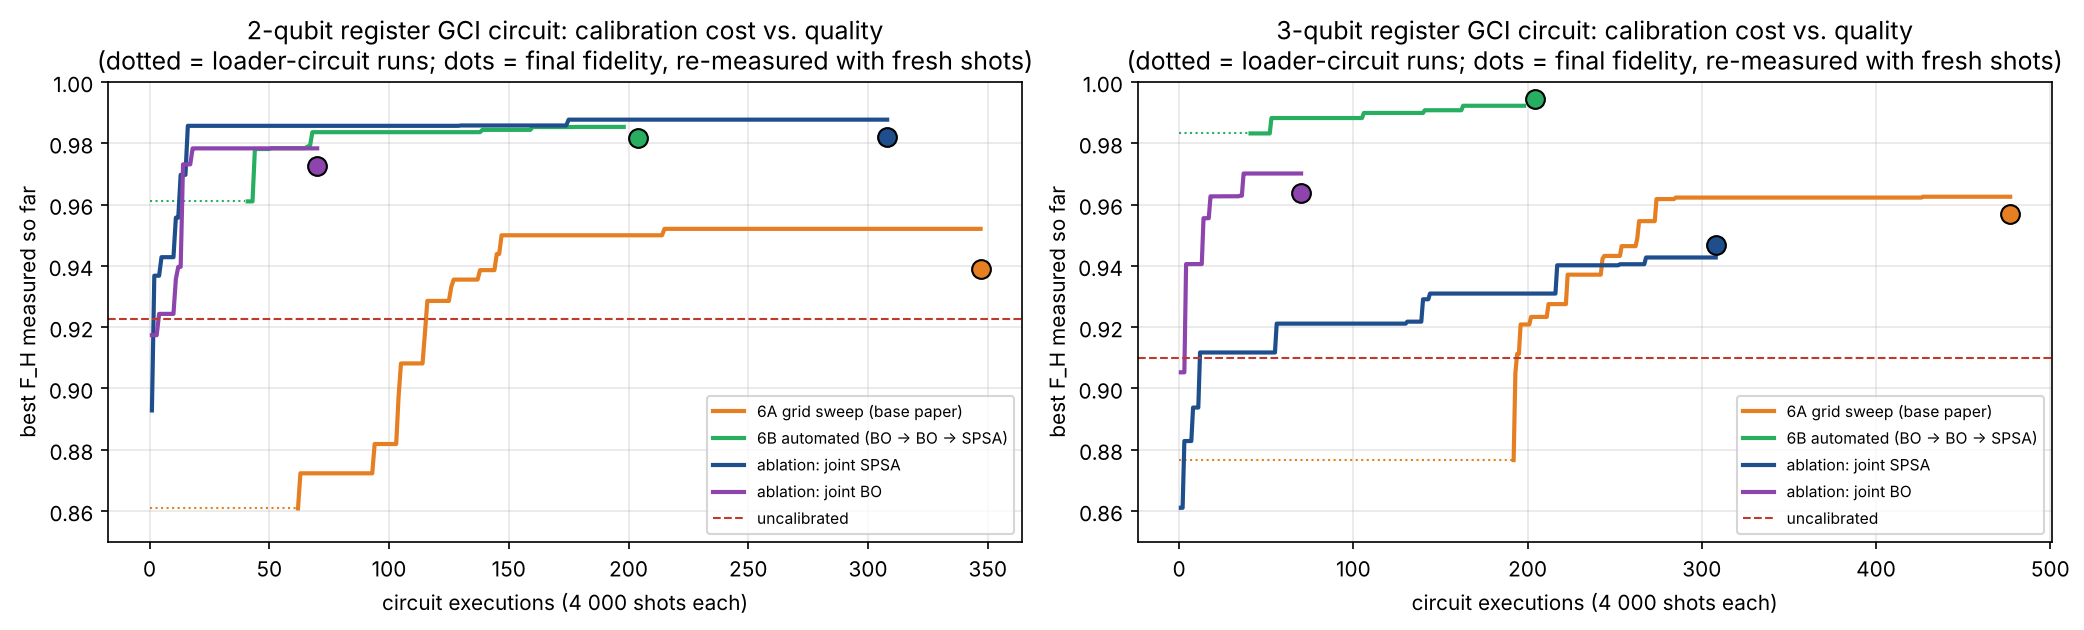

stage07_fidelity_by_variant.png


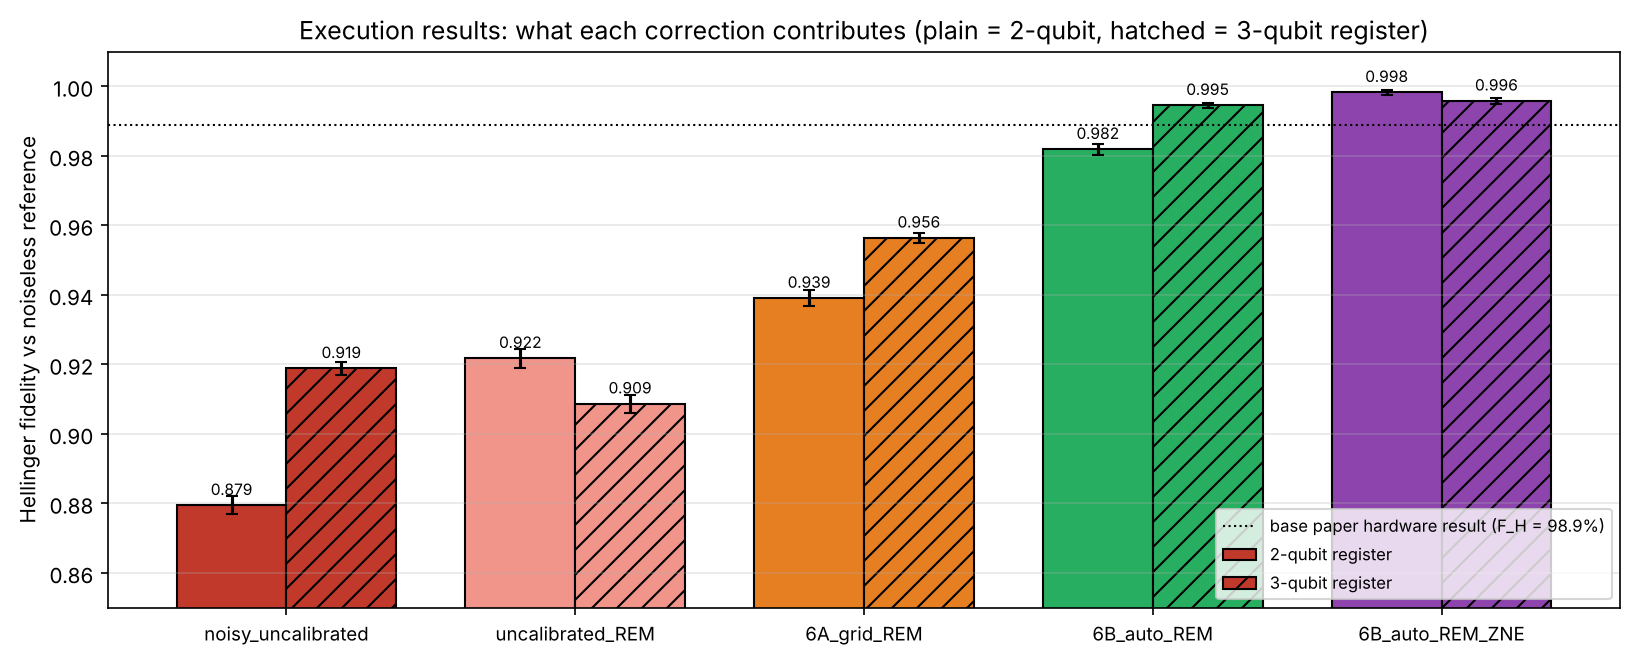

stage08_loss_cdf.png


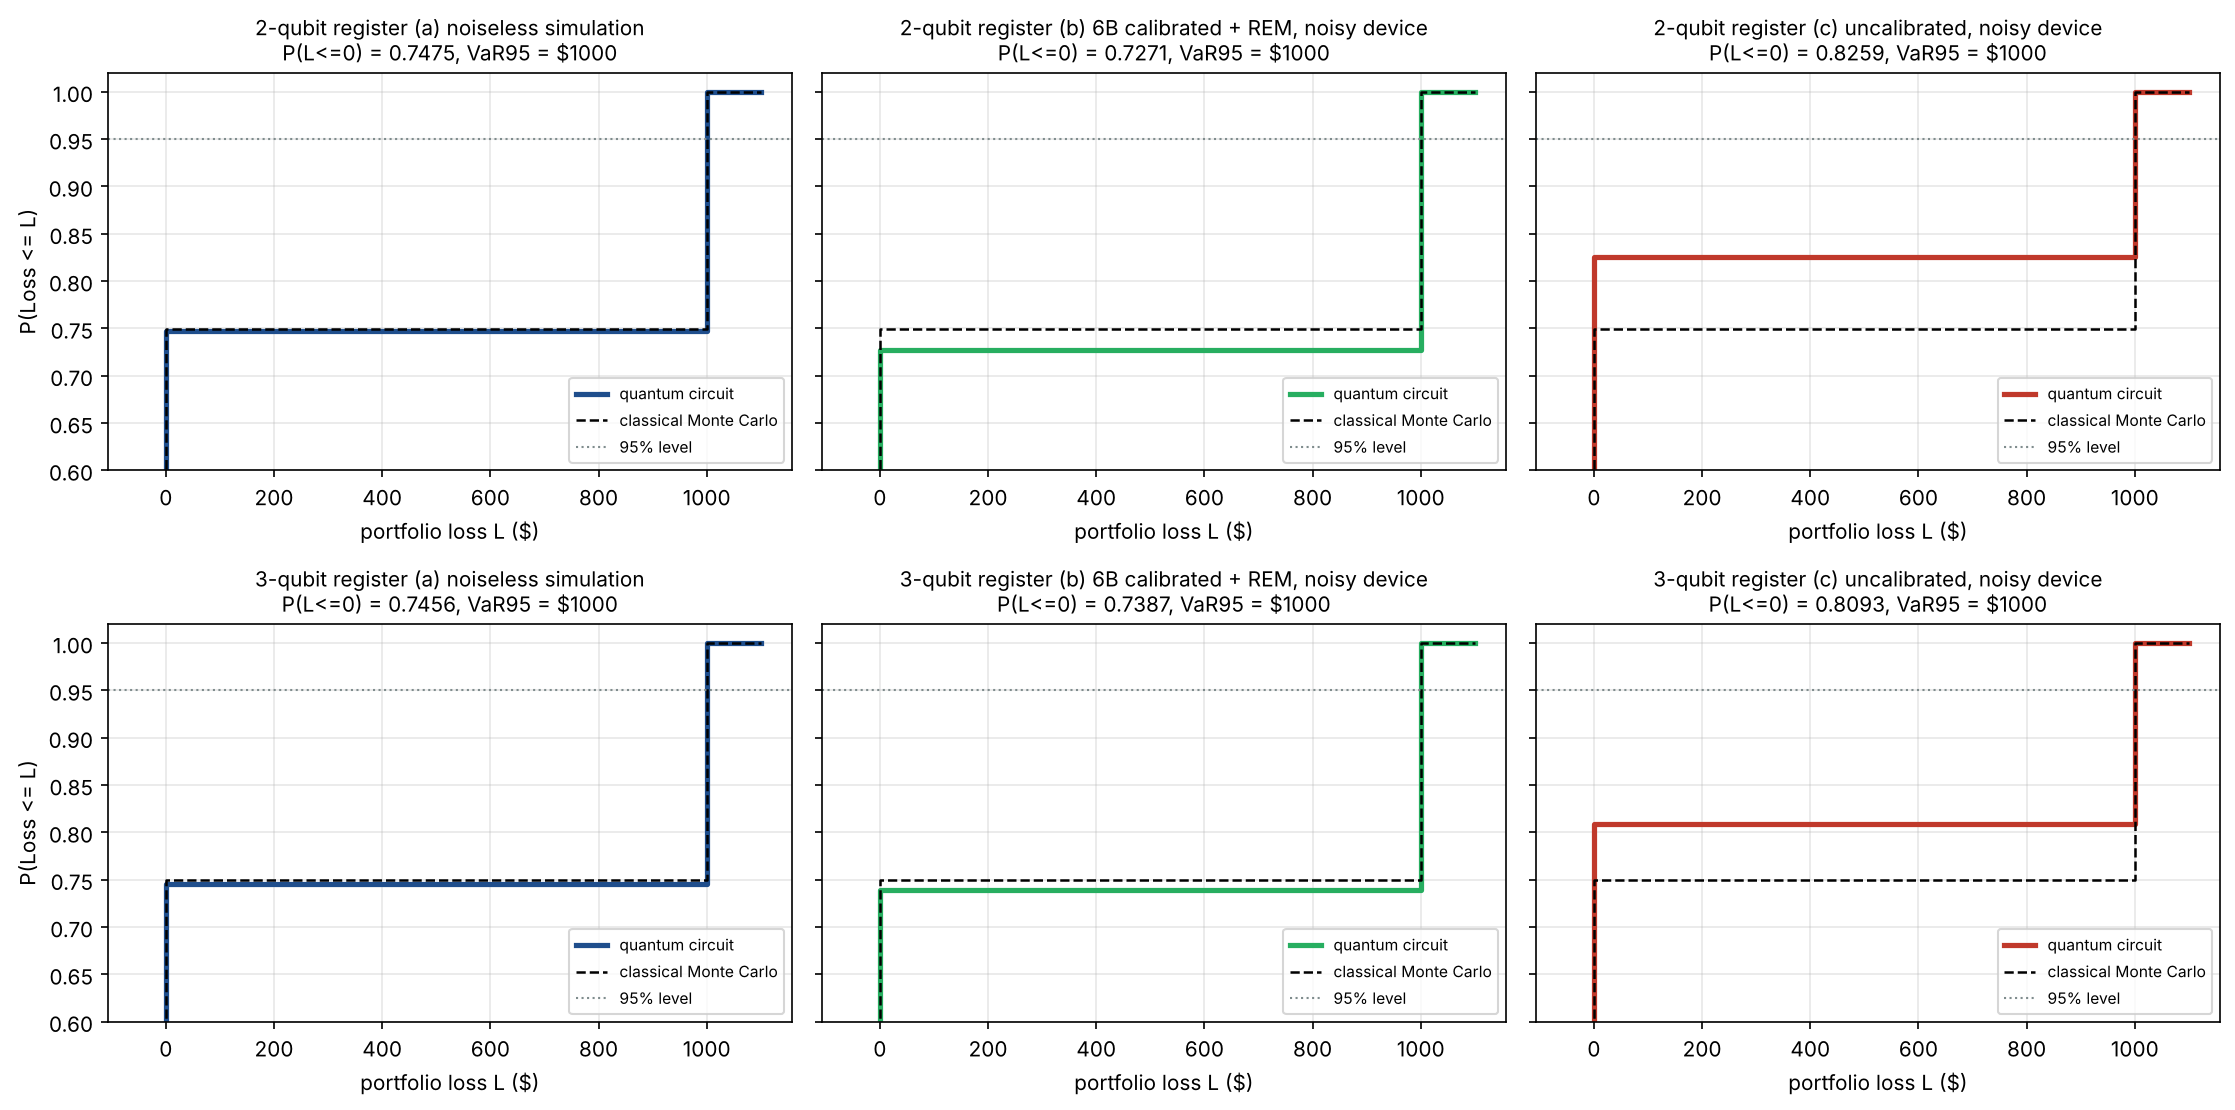

stage09_recalibration_loop.png


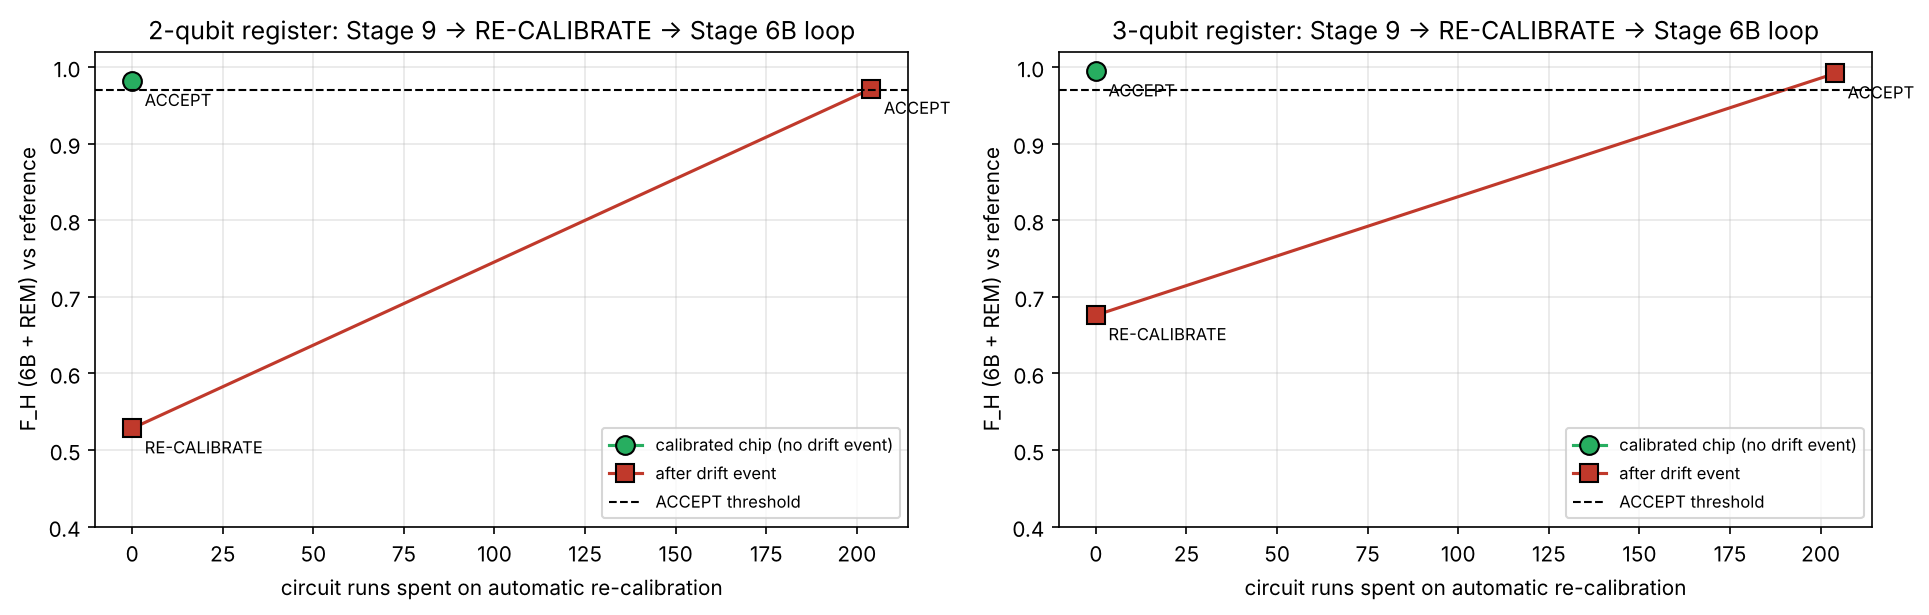

In [4]:
from IPython.display import Image, display
for f in ["stage06_convergence_gci.png", "stage07_fidelity_by_variant.png",
          "stage08_loss_cdf.png", "stage09_recalibration_loop.png"]:
    print(f)
    display(Image(filename=os.path.join("results", "figures", f), width=1000))

# User interface

In [ ]:
import subprocess, time, webbrowser, urllib.request

ui = subprocess.Popen([sys.executable, "-m", "streamlit", "run", "app.py",
                       "--server.headless", "true", "--server.port", "8501"], cwd=ROOT)
for _ in range(30):
    try:
        urllib.request.urlopen("http://localhost:8501/_stcore/health", timeout=1)
        break
    except Exception:
        time.sleep(1)
print("UI running at http://localhost:8501")
webbrowser.open("http://localhost:8501")

In [ ]:
# ui.terminate()